In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

import logging

# Setting Up Logging

In [3]:
logging.basicConfig(
    filename="sales_forecasting.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logging.info("Logging Initialized Successfully")

### Observation

Logging has been configured to track important execution events throughout the project workflow.

# Loading Datasets

In [5]:
train = pd.read_csv(
    r"C:\Users\hp\Downloads\project 6\train.csv"
)

test = pd.read_csv(r"C:\Users\hp\Downloads\project 6\test.csv")

store = pd.read_csv(r"C:\Users\hp\Downloads\project 6\store.csv")

logging.info("Datasets Loaded Successfully")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
print("Store Shape:", store.shape)

Train Shape: (1017209, 9)
Test Shape: (41088, 8)
Store Shape: (1115, 10)


### Observation

The train, test, and store datasets were loaded successfully. These datasets will be merged to create a unified dataset for further analysis.

# Merging Datasets

In [6]:
train_df = pd.merge(
    train,
    store,
    on="Store",
    how="left"
)

test_df = pd.merge(
    test,
    store,
    on="Store",
    how="left"
)

logging.info("Datasets Merged Successfully")

print(train_df.shape)
print(test_df.shape)

(1017209, 18)
(41088, 17)


### Observation

The store information was successfully merged with both training and testing datasets using the Store column as the common key.

# Viewing Sample Records

In [7]:
train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


### Observation

The initial records provide an overview of the available features, data types, and business-related information present in the dataset.

# Dataset Information

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

### Observation

Dataset information provides details about feature data types, non-null values, and potential missing values requiring preprocessing.

# Statistical Summary

In [9]:
train_df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000


### Observation

The statistical summary provides insights into feature distributions, central tendencies, and potential outliers within the dataset.

# Missing Value Analysis

In [11]:
missing_values = train_df.isnull().sum()
missing_values[
    missing_values > 0
].sort_values(
    ascending=False
)

Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
CompetitionDistance            2642
dtype: int64

### Observation

- Several columns contain missing values and require preprocessing.
- Promotion-related and competition-related features have the highest number of missing values.
- Missing value treatment is necessary before model training to improve data quality and model performance.

# Missing Value Percentage Analysis

In [12]:
missing_percentage = (
    train_df.isnull().sum()
    / len(train_df)
) * 100

missing_data = pd.DataFrame({
    "Missing Values": train_df.isnull().sum(),
    "Percentage": missing_percentage
})
missing_data[
    missing_data["Missing Values"] > 0
].sort_values(
    by="Percentage",
    ascending=False
)

,Missing Values,Percentage
Promo2SinceWeek,508031,49.943620
Promo2SinceYear,508031,49.943620
PromoInterval,508031,49.943620
CompetitionOpenSinceMonth,323348,31.787764
CompetitionOpenSinceYear,323348,31.787764
CompetitionDistance,2642,0.259730


### Observation

- Promo2SinceWeek, Promo2SinceYear, and PromoInterval contain nearly 50% missing values.
- CompetitionOpenSinceMonth and CompetitionOpenSinceYear also contain a significant percentage of missing values.
- CompetitionDistance contains a very small percentage of missing values.
- Different imputation strategies will be required for numerical and categorical features.

# Missing Value Treatment

In [13]:
train_df["CompetitionDistance"].fillna(
    train_df["CompetitionDistance"].median(),
    inplace=True
)

test_df["CompetitionDistance"].fillna(
    test_df["CompetitionDistance"].median(),
    inplace=True
)

train_df["CompetitionOpenSinceMonth"].fillna(
    0,
    inplace=True
)

test_df["CompetitionOpenSinceMonth"].fillna(
    0,
    inplace=True
)

train_df["CompetitionOpenSinceYear"].fillna(
    0,
    inplace=True
)

test_df["CompetitionOpenSinceYear"].fillna(
    0,
    inplace=True
)

train_df["Promo2SinceWeek"].fillna(
    0,
    inplace=True
)

test_df["Promo2SinceWeek"].fillna(
    0,
    inplace=True
)


train_df["Promo2SinceYear"].fillna(
    0,
    inplace=True
)

test_df["Promo2SinceYear"].fillna(
    0,
    inplace=True
)


train_df["PromoInterval"].fillna(
    "No Promo",
    inplace=True
)

test_df["PromoInterval"].fillna(
    "No Promo",
    inplace=True
)

print("Missing Values Treated Successfully")

Missing Values Treated Successfully


### Observation

Missing values were successfully handled in both training and testing datasets.

The `CompetitionDistance` feature was imputed using the median value to preserve the overall distribution and reduce the impact of outliers.

Competition-related features such as `CompetitionOpenSinceMonth` and `CompetitionOpenSinceYear` were filled with `0` to indicate unavailable competition information.

Promotion-related features such as `Promo2SinceWeek` and `Promo2SinceYear` were filled with `0` to represent stores that did not participate in the Promo2 campaign.

Missing values in the categorical feature `PromoInterval` were replaced with `"No Promo"` to preserve meaningful business information.

The dataset is now free from missing values and ready for feature engineering and exploratory data analysis.

## Missing Value Verification

In [17]:
print("Train Missing Values :", train_df.isnull().sum().sum())

print("Test Missing Values :", test_df.isnull().sum().sum())

Train Missing Values : 0
Test Missing Values : 0


### Observation

🟢 All missing values have been successfully treated in both training and testing datasets.

🟢 The `Open` column contained 11 missing values in the test dataset and was imputed using the mode (most frequent value).

🟢 Appropriate imputation techniques were applied based on the nature of each feature.

🟢 The datasets are now free from null values and ready for feature engineering and exploratory data analysis.

🟢 Clean and complete data will help improve model performance and prediction reliability.

# Date Feature Engineering


In [18]:


train_df["Date"] = pd.to_datetime(
    train_df["Date"]
)

test_df["Date"] = pd.to_datetime(
    test_df["Date"]
)

train_df["Year"] = train_df["Date"].dt.year
train_df["Month"] = train_df["Date"].dt.month
train_df["Day"] = train_df["Date"].dt.day
train_df["Weekday"] = train_df["Date"].dt.weekday
train_df["Quarter"] = train_df["Date"].dt.quarter

train_df["IsWeekend"] = train_df[
    "Weekday"
].apply(
    lambda x: 1 if x >= 5 else 0
)

test_df["Year"] = test_df["Date"].dt.year
test_df["Month"] = test_df["Date"].dt.month
test_df["Day"] = test_df["Date"].dt.day
test_df["Weekday"] = test_df["Date"].dt.weekday
test_df["Quarter"] = test_df["Date"].dt.quarter

test_df["IsWeekend"] = test_df[
    "Weekday"
].apply(
    lambda x: 1 if x >= 5 else 0
)

print("Date Features Extracted Successfully")

Date Features Extracted Successfully


### Observation

🟢 The Date column was successfully converted into datetime format.

🟢 Several useful time-based features such as Year, Month, Day, Weekday, Quarter, and IsWeekend were extracted.

🟢 These features help capture seasonality, trends, and customer purchasing patterns over time.

🟢 Temporal features are important for improving sales forecasting accuracy.

# Duplicate Value Check


In [20]:
print(
    "Duplicate Rows in Train Dataset :",
    train_df.duplicated().sum()
)

print(
    "Duplicate Rows in Test Dataset :",
    test_df.duplicated().sum()
)

Duplicate Rows in Train Dataset : 0
Duplicate Rows in Test Dataset : 0


### Observation

🟢 Duplicate records were checked in both datasets.

🟢 No duplicate observations were found.

🟢 The datasets are clean and suitable for further analysis and feature engineering.

# Sales Distribution Analysis



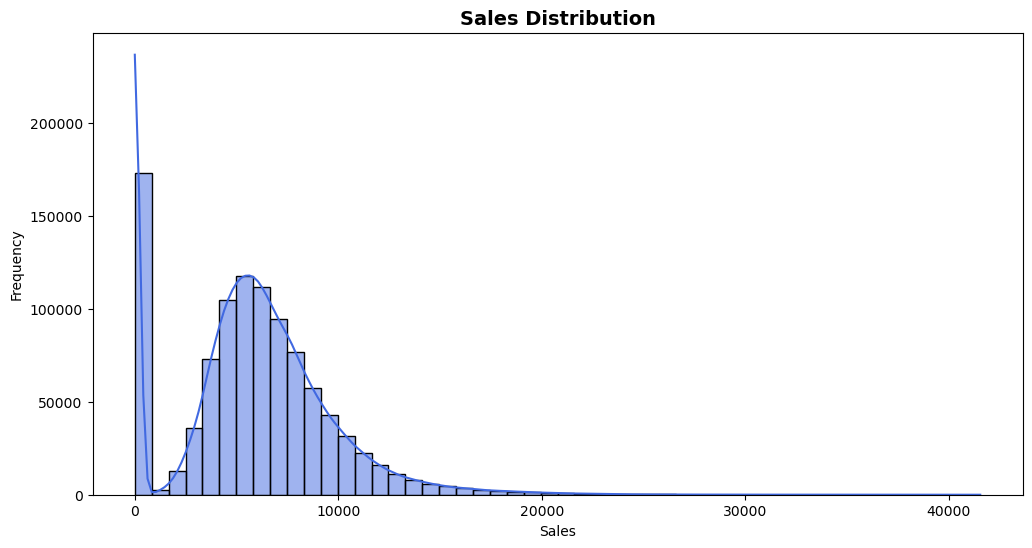

In [21]:
plt.figure(figsize=(12,6))

sns.histplot(
    train_df["Sales"],
    bins=50,
    kde=True,
    color="royalblue"
)

plt.title(
    "Sales Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.show()

### Observation

🟢 Sales values are not uniformly distributed across stores.

🟢 Most stores generate sales within a specific range, while a smaller number of stores achieve significantly higher sales.

🟢 The distribution suggests the presence of variability and possible outliers that may influence forecasting performance.

# Customers vs Sales Analysis

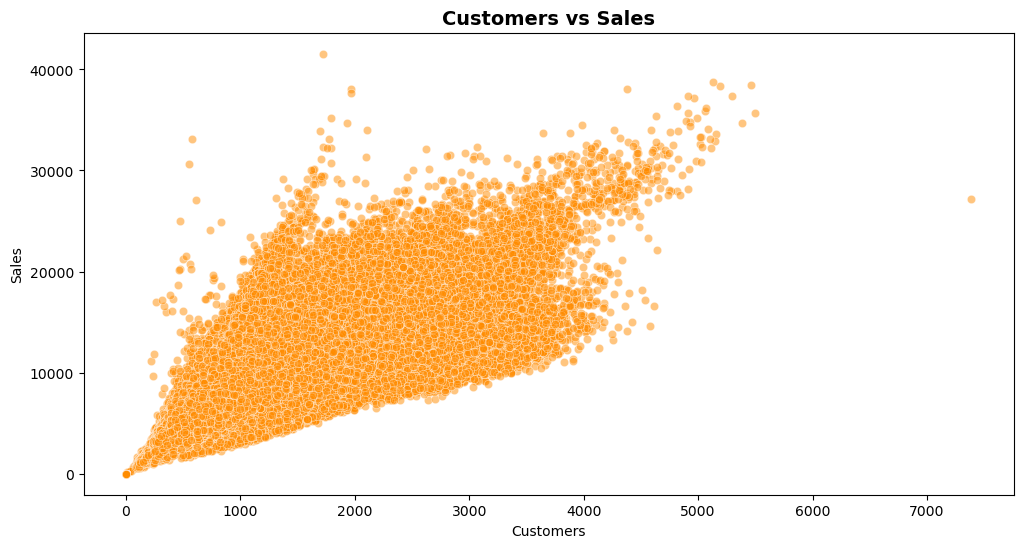

In [22]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    x="Customers",
    y="Sales",
    data=train_df,
    color="darkorange",
    alpha=0.5
)

plt.title(
    "Customers vs Sales",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Customers")
plt.ylabel("Sales")

plt.show()

### Observation

🟢 A positive relationship exists between customer count and sales.

🟢 Stores with a higher number of customers generally generate higher sales.

🟢 Customer traffic is one of the most influential factors affecting store revenue.

# Promotion Impact Analysis



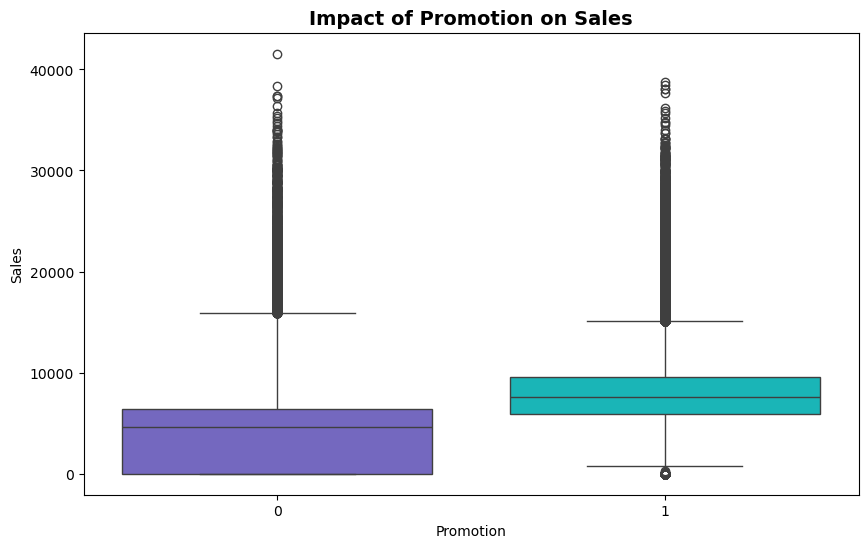

In [23]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Promo",
    y="Sales",
    data=train_df,
    palette=["#6A5ACD", "#00CED1"]
)

plt.title(
    "Impact of Promotion on Sales",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Promotion")
plt.ylabel("Sales")

plt.show()

### Observation

🟢 Stores running promotions tend to achieve higher sales compared to stores without promotions.

🟢 Promotional activities appear to have a positive effect on customer purchasing behavior.

🟢 Promotions can be considered an important sales-driving factor.

# Holiday Impact Analysis

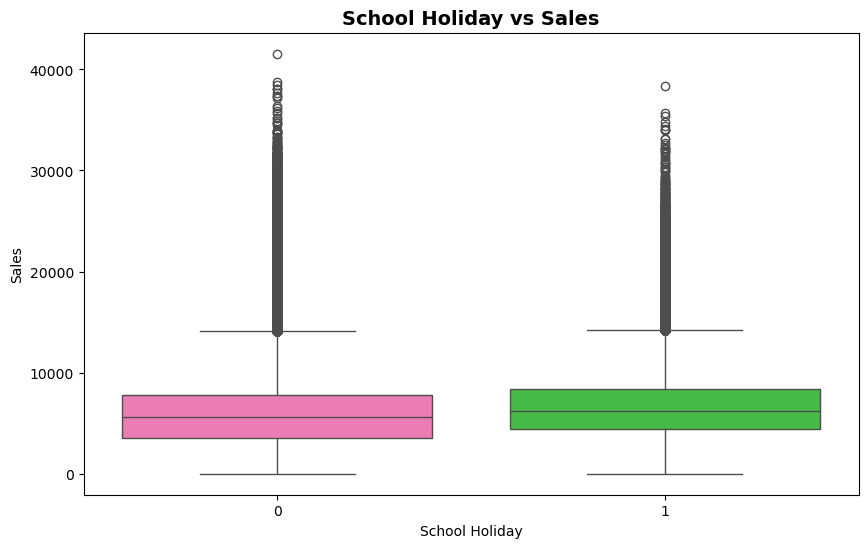

In [24]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="SchoolHoliday",
    y="Sales",
    data=train_df,
    palette=["#FF69B4", "#32CD32"]
)

plt.title(
    "School Holiday vs Sales",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("School Holiday")
plt.ylabel("Sales")

plt.show()

### Observation

🟢 Sales patterns vary between holiday and non-holiday periods.

🟢 School holidays can influence customer shopping behavior depending on store location and product demand.

🟢 Holiday-related factors should be considered during forecasting.

# Competition Distance Analysis


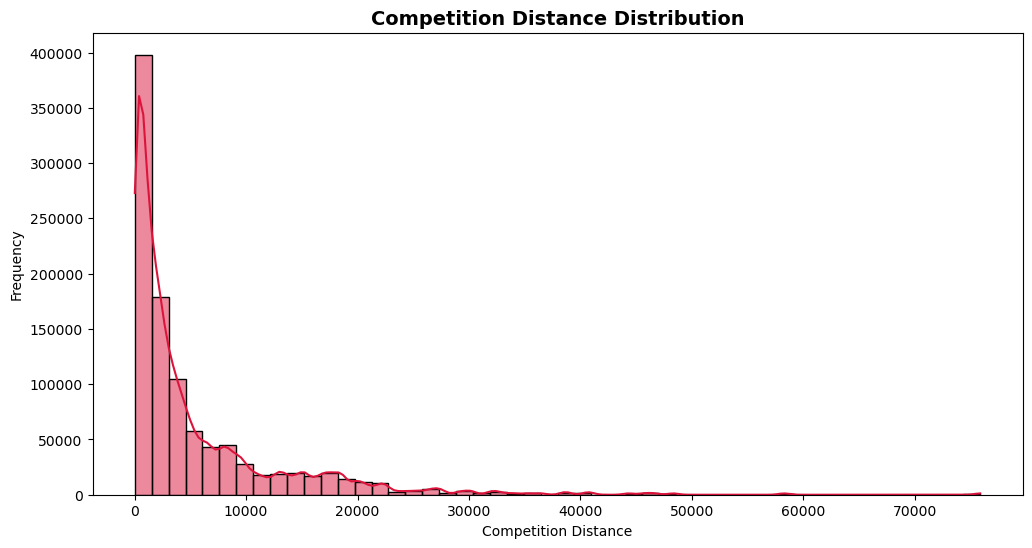

In [25]:
plt.figure(figsize=(12,6))

sns.histplot(
    train_df["CompetitionDistance"],
    bins=50,
    kde=True,
    color="crimson"
)

plt.title(
    "Competition Distance Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Competition Distance")
plt.ylabel("Frequency")

plt.show()

### Observation

🟢 Competition distances vary significantly across stores.

🟢 Some stores face nearby competition while others operate with limited competitive pressure.

🟢 Competition distance may influence store sales and customer traffic patterns.

# Store Type Analysis


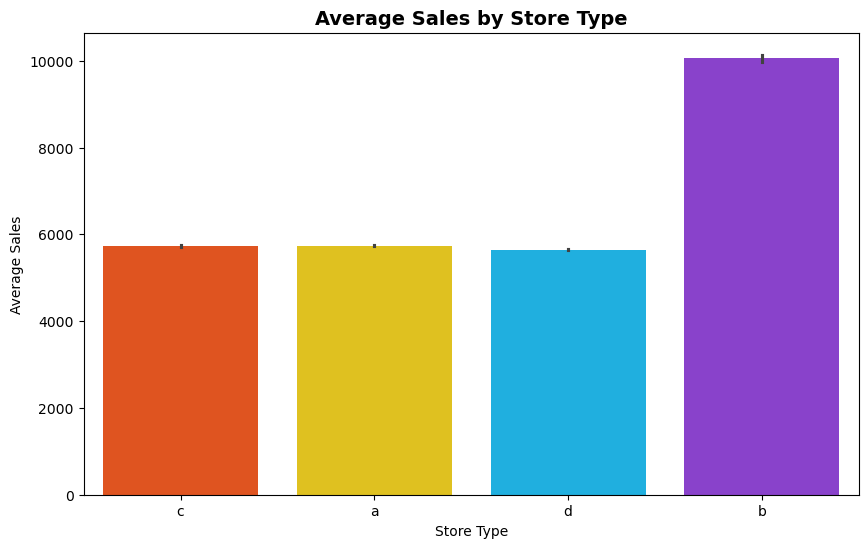

In [27]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="StoreType",
    y="Sales",
    data=train_df,
    palette=["#FF4500","#FFD700","#00BFFF","#8A2BE2"]
)

plt.title(
    "Average Sales by Store Type",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Store Type")
plt.ylabel("Average Sales")

plt.show()

### Observation

🟢 Sales performance differs across store types.

🟢 Certain store categories generate higher average sales than others.

🟢 Store type is likely to be an important predictor in the forecasting model.

# Correlation Analysis

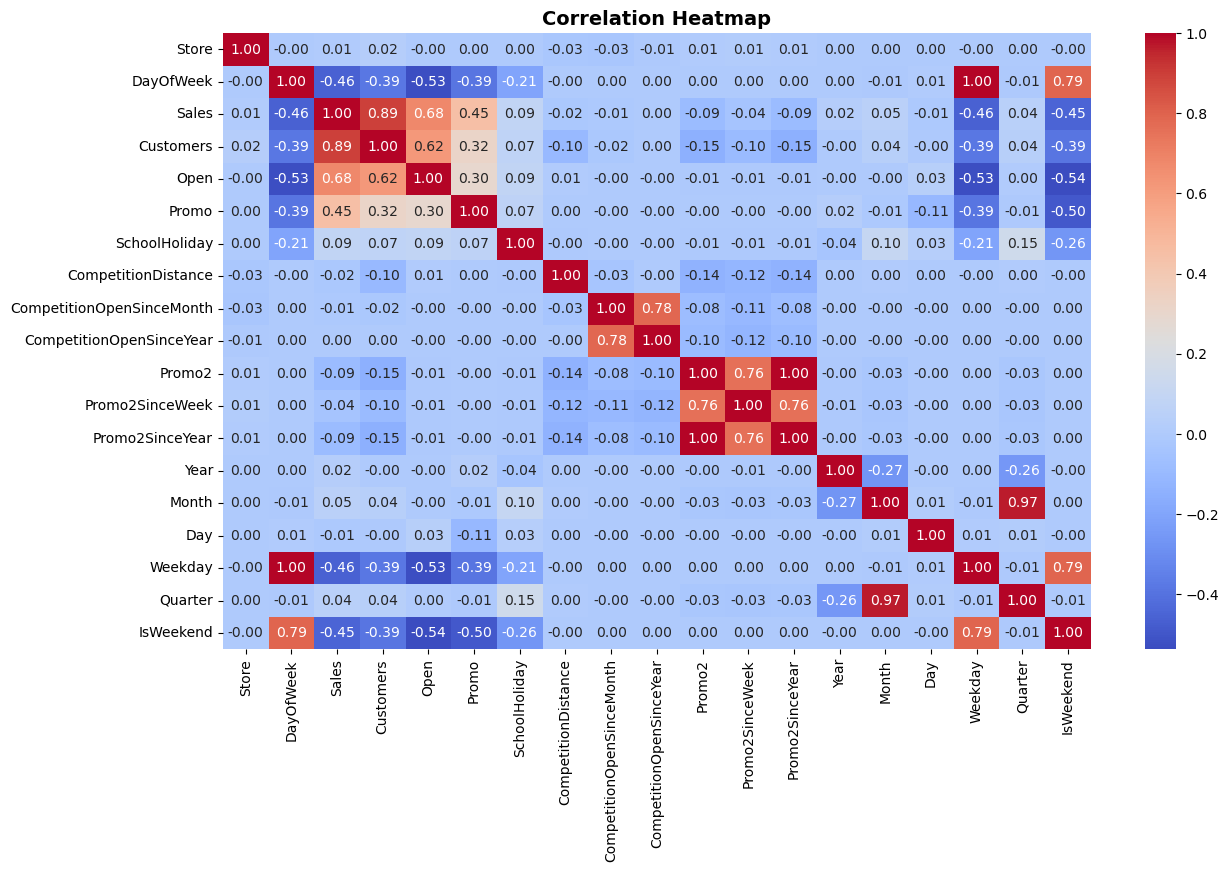

In [28]:
plt.figure(figsize=(14,8))

sns.heatmap(
    train_df.select_dtypes(
        include=np.number
    ).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Correlation Heatmap",
    fontsize=14,
    fontweight="bold"
)

plt.show()

### Observation

🟢 Sales show varying levels of correlation with different numerical features.

🟢 Customer count generally exhibits a strong positive relationship with sales.

🟢 Correlation analysis helps identify influential variables for model development.

🟢 Highly correlated features may contribute significantly to forecasting accuracy.

# Categorical Feature Encoding

In [29]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

categorical_columns = [
    "StateHoliday",
    "StoreType",
    "Assortment",
    "PromoInterval"
]

for column in categorical_columns:
    
    train_df[column] = label_encoder.fit_transform(
        train_df[column].astype(str)
    )
    
    test_df[column] = label_encoder.transform(
        test_df[column].astype(str)
    )

print("Categorical Features Encoded Successfully")

Categorical Features Encoded Successfully


### Observation

🟢 Categorical features were converted into numerical format using Label Encoding.

🟢 Label Encoding reduces dimensionality compared to One-Hot Encoding.

🟢 Encoded features can now be used directly by machine learning algorithms.

🟢 The dataset is now closer to a model-ready format.

# Feature Scaling

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_columns = [
    "CompetitionDistance",
    "Year",
    "Month",
    "Day",
    "Weekday",
    "Quarter"
]

train_df[numerical_columns] = scaler.fit_transform(
    train_df[numerical_columns]
)

test_df[numerical_columns] = scaler.transform(
    test_df[numerical_columns]
)

print("Feature Scaling Completed Successfully")

Feature Scaling Completed Successfully


### Observation

🟢 Numerical features were standardized using StandardScaler.

🟢 Feature scaling transforms variables to a common scale while preserving relationships within the data.

🟢 Standardized features can improve model stability and training efficiency for scale-sensitive algorithms.

🟢 The dataset is now fully preprocessed and ready for machine learning model development.

# Final Dataset Verification


In [31]:
train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,Weekday,Quarter,IsWeekend
0,1,5,2015-07-31,5263,555,1,1,0,1,2,...,0,0.0,0.0,3,1.502077,0.346724,1.740766,0.501484,0.652353,0
1,2,5,2015-07-31,6064,625,1,1,0,1,0,...,1,13.0,2010.0,1,1.502077,0.346724,1.740766,0.501484,0.652353,0
2,3,5,2015-07-31,8314,821,1,1,0,1,0,...,1,14.0,2011.0,1,1.502077,0.346724,1.740766,0.501484,0.652353,0
3,4,5,2015-07-31,13995,1498,1,1,0,1,2,...,0,0.0,0.0,3,1.502077,0.346724,1.740766,0.501484,0.652353,0
4,5,5,2015-07-31,4822,559,1,1,0,1,0,...,0,0.0,0.0,3,1.502077,0.346724,1.740766,0.501484,0.652353,0


In [32]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 24 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  int64         
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  int64         
 10  Assortment                 1017209 non-null  int64         
 11  CompetitionDistance        1017209 no

In [33]:
test_df.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,...,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,Weekday,Quarter,IsWeekend
0,1,1,4,2015-09-17,1.0,1,0,0,2,0,...,0,0.0,0.0,3,1.502077,0.94803,0.147618,0.000831,0.652353,0
1,2,3,4,2015-09-17,1.0,1,0,0,0,0,...,1,14.0,2011.0,1,1.502077,0.94803,0.147618,0.000831,0.652353,0
2,3,7,4,2015-09-17,1.0,1,0,0,0,2,...,0,0.0,0.0,3,1.502077,0.94803,0.147618,0.000831,0.652353,0
3,4,8,4,2015-09-17,1.0,1,0,0,0,0,...,0,0.0,0.0,3,1.502077,0.94803,0.147618,0.000831,0.652353,0
4,5,9,4,2015-09-17,1.0,1,0,0,0,2,...,0,0.0,0.0,3,1.502077,0.94803,0.147618,0.000831,0.652353,0


### Observation

🟢 All preprocessing steps have been completed successfully.

🟢 Missing values have been handled, categorical variables encoded, and numerical features standardized.

🟢 Date-based features have been extracted to capture temporal sales patterns.

🟢 The datasets are now ready for machine learning model development in the next notebook.